This tutorial demonstrates how to __read a time slice from a SEG-Y data set__. The 3D test data is the F3 2023 demo data set - for details, please check the README in the data folder.

Let's start by importing some packages (including the __seisio__ package itself) and setting up the logging config.

In [1]:
import logging
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.insert(1, '../')
import seisio

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s', force=True)
log = logging.getLogger("main")

We would like to read the 3D seismic file called "Seismic_data.sgy". First of all, let's get an overview of the data:

In [2]:
file = "data/Seismic_data.sgy"
sio = seisio.input(file)
thstat = sio.log_thstat()

INFO: Input file: data/Seismic_data.sgy
INFO: Input file is local? True
INFO: SEG-Y textual file header encoding looks to be 'ASCII' (best guess).
INFO: Input file endianess looks to be '>' (best guess).
INFO: SEG-Y revision (according to binary header): 1.0
INFO: Data sample format: 2-byte two's complement integer.
INFO: SEG-Y fixed-trace-length flag is set in binary header.
INFO: Number of additional textual header records: 0.
INFO: Number of trailer stanza records: 0.
INFO: SEG-Y trace header extension 1 is not present.
INFO: Number of user-defined trace headers: 0
INFO: Byte offset of first trace relative to start of file: 3600 bytes.
INFO: Number of samples per data trace: 462.
INFO: Sampling interval: 4000 (unit as per SEG-Y standard).
INFO: Number of data traces in file: 600515.
INFO: Delay (on first trace): 4 (unit as per SEG-Y standard).
INFO: Coordinate scaler (on first trace): -10.
INFO: Elevation scaler (on first trace): 0.
INFO: Calculating trace header statistics.
INFO: R

The actual data are given as integer values (2-byte two's complement integers). The inline and crossline ranges correspond to the information given on the F3 demo data set download site. It seems the inline and crossline headers have also been copied to the "fldr" and "cdp" mnemonics. There are 462 time slices in the data, the first time slice at time 0.004 seconds (see "delrt" mnemonic). Therefore, the maximum time is 1.848 seconds, a value also mentioned on the download site. Let's try and read a time slice about 1/3 down the vertical axis:


In [3]:
try:
    nsl = sio.ns//3
    vslice = sio.read_vslice(n=nsl)
except ValueError as v:
    log.error("Error was: '%s'", v)

INFO: Reading vertical slice at index 154...
INFO: Reading vertical slice took 0.2 seconds.
INFO: Cube dimensions: (951, 651, 1)
INFO: I defined by: 'xline' (300 to 1250, increment 1)
INFO: J defined by: 'iline' (100 to 750, increment 1)
INFO: Ensemble2cube is padding 18586 trace(s).
ERROR: Error was: 'cannot convert float NaN to integer'


Why did this fail? In order to create a fully populated time slice, **seisio** tried to pad trace positions using (by default) a fill value of np.nan. This, however, only works if the actual data are given as floating-point numbers. In our case, as mentioned above, the actual data are given as integer numbers. We therefore have to use an additional parameter to tell the reader method to use a different fill value. So let's try again:

In [4]:
nsl = sio.ns//3
vslice = sio.read_vslice(n=nsl, fill_value=0)

INFO: Reading vertical slice at index 154...
INFO: Reading vertical slice took 0.2 seconds.
INFO: Cube dimensions: (951, 651, 1)
INFO: I defined by: 'xline' (300 to 1250, increment 1)
INFO: J defined by: 'iline' (100 to 750, increment 1)
INFO: Ensemble2cube is padding 18586 trace(s).


This time it worked. By default, *read_vslice()* uses the crossline and inline mnemonics to define the "I" and "J" axes. The dimensions are (951, 651, 1), i.e., we have 951 different crossline numbers, 651 different inline numbers, and 1 (time) sample. Let's try and visualize the time slice:

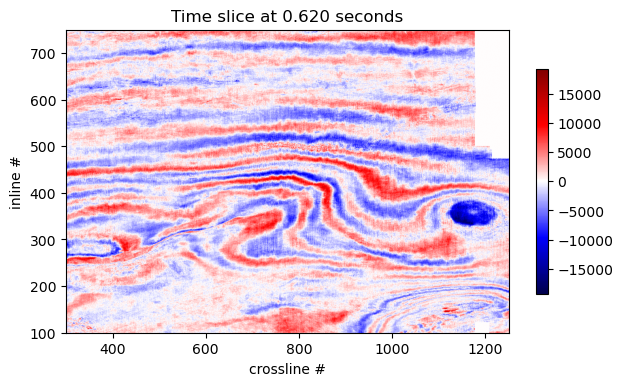

In [5]:
data = vslice["data"].squeeze()
haxis = vslice[:, 0]["xline"]
vaxis = vslice[0, :]["iline"]

extent = [haxis[0], haxis[-1], vaxis[0], vaxis[-1]]
clip = np.max(np.abs(data))

fig, ax = plt.subplots(1, 1)
im = ax.imshow(data, extent=extent, vmin=-clip, vmax=clip, aspect="equal", cmap="seismic")
ax.set_xlabel("crossline #")
ax.set_ylabel("inline #")
ax.set_title(f"Time slice at {sio.delay*1e-3+nsl*sio.vsi*1e-6:.3f} seconds")
cbar = fig.colorbar(im, ax=ax, shrink=0.5)
    
plt.tight_layout()
plt.show()

Let's see whether we get the same result with **segyio**. There is one complication, though. As opposed to **seisio**, this package can only read slices from regular cubes. So we have to use a workaround:

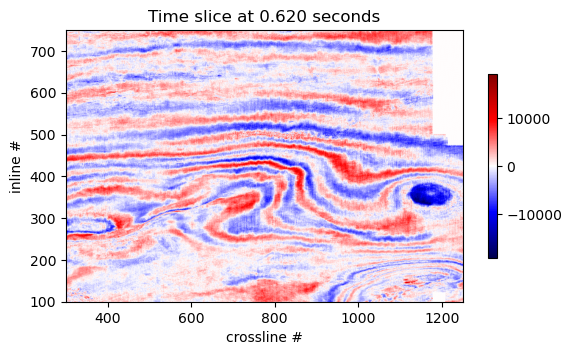

In [6]:
import segyio

with segyio.open(file, ignore_geometry=True) as f:
    # 1. Read all inline and crossline headers to find the unique grid limits
    ilines = f.attributes(segyio.TraceField.INLINE_3D)[:]
    xlines = f.attributes(segyio.TraceField.CROSSLINE_3D)[:]
    unique_ils = np.unique(ilines)
    unique_xls = np.unique(xlines)
    # 2. Setup target slice info
    target_sample_idx = nsl
    # Create an empty, regular 2D grid filled with 0 
    slice_grid = np.zeros((len(unique_xls), len(unique_ils)), dtype=int) 
    # Create fast lookup dictionaries for indices
    il_to_idx = {il: idx for idx, il in enumerate(unique_ils)}
    xl_to_idx = {xl: idx for idx, xl in enumerate(unique_xls)}
    # 3. Read the specific sample from every trace and map it to the grid
    for trace_idx in range(f.tracecount):
        il = ilines[trace_idx]
        xl = xlines[trace_idx]
        i = il_to_idx[il]
        j = xl_to_idx[xl]
        slice_grid[j, i] = f.trace[trace_idx][target_sample_idx]

extent2 = [unique_xls[0], unique_xls[-1], unique_ils[0], unique_ils[-1]]
clip2 = np.max(np.abs(slice_grid))

fig2, ax2 = plt.subplots(1, 1)
im2 = ax2.imshow(slice_grid, extent=extent2, vmin=-clip2, vmax=clip2, aspect="equal", cmap="seismic")
ax2.set_xlabel("crossline #")
ax2.set_ylabel("inline #")
ax2.set_title(f"Time slice at {sio.delay*1e-3+nsl*sio.vsi*1e-6:.3f} seconds")
cbar2 = fig2.colorbar(im2, ax=ax2, shrink=0.5)

This looks pretty good. Let's make sure the slices actually contain the same data values:

In [7]:
log.info("Maximum difference: %f", np.max(data - slice_grid))

INFO: Maximum difference: 0.000000


The difference is 0, i.e., the same data were read. The automatic padding offered by **seisio** seems quite convenient. If the data are sorted on disk and perfectly regular, **seisio** will automatically use a fast numpy.reshape method rather than going through the padding procedure.